2.7995030600952306


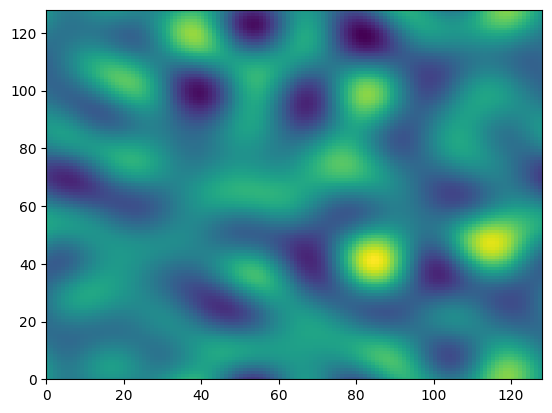

In [229]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft

nx = 128
ny = 128
Lx = 1
mu = 0.0
sigma = 1.0
rng = np.random.default_rng(seed=1990)

h0 = rng.normal(loc=0.0, scale=10.0, size=(nx,ny)) # + 1000.0 # uncomment to check mid
hf = fft.fftshift(fft.fft2(h0))
#print(np.unravel_index(np.argmax(hf),hf.shape))
mid = 64
for i in range(0,nx):
    for j in range(0,ny):
        invq = np.sqrt((i-mid)**2+(j-mid)**2)
        # applying bandpass filter
        if (1.0 < invq < 6.0):
            hf[i,j] = hf[i,j]#/invq**(1.8) #, uncomment this to get something more realistic (1.8=1+H, where H is Hurst exponent)
        else:
            hf[i,j] = 0

h = fft.ifft2(fft.ifftshift(hf))
h = np.real(h)
print(np.amax(h))
plt.pcolor(np.real(h))

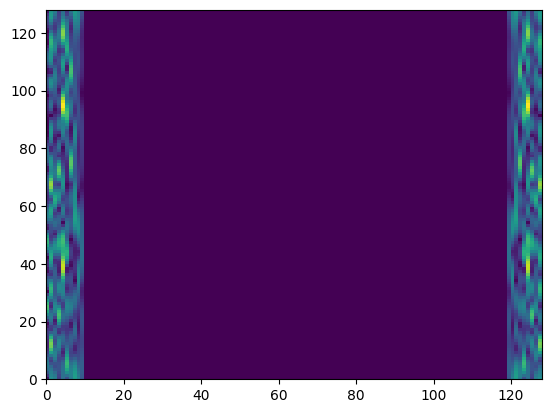

In [178]:
f = fft.fft(h)
plt.pcolor(np.absolute(f))

In [234]:
npts = 129
Lpts = npts-1
x1 = np.linspace(0,Lpts,npts)
y1 = np.linspace(0,Lpts,npts)
z1 = np.linspace(0,Lpts,npts)
x3, y3, z3 = np.meshgrid(x1,y1,z1,indexing='ij')

h_big = np.zeros((npts,npts))
h_big[:-1,:-1] = h
h_big[-1,:-1] = h_big[0,:-1]
h_big[:-1,-1] = h_big[:-1,0]

phi_init = np.ones_like(x3)

ell = 4.0*Lpts/40.0
for i in range(0,npts):
    for j in range(0,npts):
        for k in range(0,npts):
            distpt = y3[i,j,k] - (h_big[i,k] + 0.75*Lpts)
            if ( distpt > ell/2.0 ):
                phi_init[i,j,k] = 0.0
            else:
                if ( distpt < -ell/2.0 ):
                    phi_init[i,j,k] = 1.0
                else:
                    phi_init[i,j,k] = 0.5 - 0.5*np.sin(np.pi/ell*distpt)
print(np.amax(phi_init))

1.0


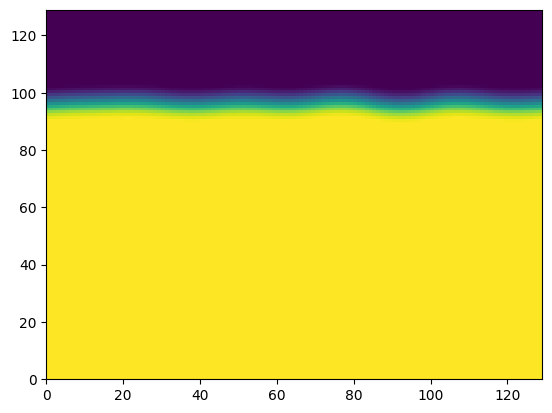

In [235]:
plt.pcolor(phi_init[80,:,:])

In [237]:
f = open("dealloy_phi.in",'wb')
f.write(phi_init.tobytes(order='F'))
f.close()